# Student Performance & Academic Risk Analysis


##  Project Overview
### Project objectives
The goal of this project is to identify students who are at risk of poor academic performance using demographic, behavioural, family and academic data. Exploratory Data Analysis(EDA) was used to uncover factors influencing student performance, while machine learning models were developed to predict whether a student is academically at risk.
### Dataset
The dataset contains information on students' demographic characteristics, family background, study habits, attendance, previous grades and final academic performance.
### Technologies used
*   Python
*   Pandas
*   Numpy
*   Matplotlib
*   Seaborn
*   Scikit-learn









## Import Libraries / Load Dataset

In [4]:
from google.colab import files
uploaded= files.upload()

Saving student_performance.csv to student_performance.csv


In [43]:
import pandas as pd
import numpy as np

#load the data set
df=pd.read_csv('student_performance.csv')
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


## Data Cleaning

In [44]:
# Dataset dimensions
print('Rows:', df.shape[0])
print('columns:',df.shape[1])

Rows: 649
columns: 33


In [7]:
print('\ncolumns:')
print(df.columns.tolist())


columns:
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']


In [45]:
# Basic dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      649 non-null    object
 1   sex         649 non-null    object
 2   age         649 non-null    int64 
 3   address     649 non-null    object
 4   famsize     649 non-null    object
 5   Pstatus     649 non-null    object
 6   Medu        649 non-null    int64 
 7   Fedu        649 non-null    int64 
 8   Mjob        649 non-null    object
 9   Fjob        649 non-null    object
 10  reason      649 non-null    object
 11  guardian    649 non-null    object
 12  traveltime  649 non-null    int64 
 13  studytime   649 non-null    int64 
 14  failures    649 non-null    int64 
 15  schoolsup   649 non-null    object
 16  famsup      649 non-null    object
 17  paid        649 non-null    object
 18  activities  649 non-null    object
 19  nursery     649 non-null    object
 20  higher    

In [9]:
df.isnull().sum().sum()

np.int64(0)

In [10]:
# Summary statistic for the variables
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,649.0,16.744222,1.218138,15.0,16.0,17.0,18.0,22.0
Medu,649.0,2.514638,1.134552,0.0,2.0,2.0,4.0,4.0
Fedu,649.0,2.306626,1.099931,0.0,1.0,2.0,3.0,4.0
traveltime,649.0,1.568567,0.748660,1.0,1.0,1.0,2.0,4.0
studytime,649.0,1.930663,0.829510,1.0,1.0,2.0,2.0,4.0
failures,649.0,0.221880,0.593235,0.0,0.0,0.0,0.0,3.0
famrel,649.0,3.930663,0.955717,1.0,4.0,4.0,5.0,5.0
freetime,649.0,3.180277,1.051093,1.0,3.0,3.0,4.0,5.0
goout,649.0,3.184900,1.175766,1.0,2.0,3.0,4.0,5.0
Dalc,649.0,1.502311,0.924834,1.0,1.0,1.0,2.0,5.0


In [11]:
df.describe(include='object').T

,count,unique,top,freq
school,649,2,GP,423
sex,649,2,F,383
address,649,2,U,452
famsize,649,2,GT3,457
Pstatus,649,2,T,569
Mjob,649,5,other,258
Fjob,649,5,other,367
reason,649,4,course,285
guardian,649,3,mother,455
schoolsup,649,2,no,581


In [12]:
# Unique values in each column
df.nunique().sort_values()

,0
school,2
sex,2
address,2
famsize,2
Pstatus,2
schoolsup,2
paid,2
famsup,2
nursery,2
romantic,2


In [13]:
df[['G1','G2','G3']].describe().T

,count,mean,std,min,25%,50%,75%,max
G1,649.0,11.399076,2.745265,0.0,10.0,11.0,13.0,19.0
G2,649.0,11.570108,2.913639,0.0,10.0,11.0,13.0,19.0
G3,649.0,11.906009,3.230656,0.0,10.0,12.0,14.0,19.0


In [14]:
df['G3'].value_counts().sort_index()

,count
G3,
0,15
1,1
5,1
6,3
7,10
8,35
9,35
10,97
11,104


# Exploratory Data Analysis

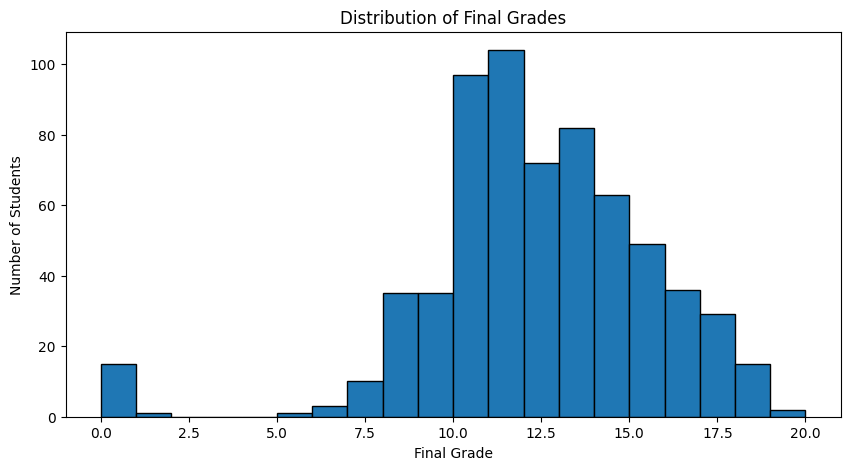

In [15]:
# How well are students performing overall and what proportion may be considered academically at risk?
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
plt.hist(df['G3'],bins=range(0,21), edgecolor='black')
plt.xlabel('Final Grade')
plt.ylabel('Number of Students')
plt.title('Distribution of Final Grades')
plt.show()


In [16]:
# performance by study time
df.groupby('studytime')['G3'].agg(['count','mean','median','min','max']).round()

,count,mean,median,min,max
studytime,,,,,
1,212,11.0,11.0,0,18
2,305,12.0,12.0,0,19
3,97,13.0,13.0,8,18
4,35,13.0,13.0,6,19


<Figure size 1000x500 with 0 Axes>

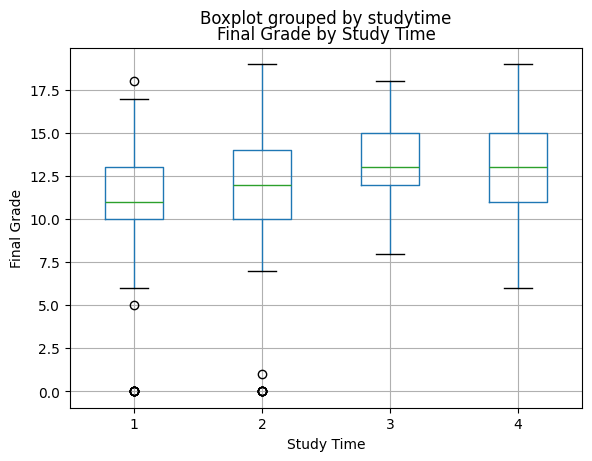

In [17]:
plt.figure(figsize=(10,5))
df.boxplot(column='G3',by='studytime')
plt.xlabel('Study Time')
plt.ylabel('Final Grade')
plt.title('Final Grade by Study Time')
plt.show()

In [18]:
df[['studytime','G3']].corr()
#df['studytime'].corr(df['G3'])


,studytime,G3
studytime,1.000000,0.249789
G3,0.249789,1.000000


In [19]:
# Correlation between absences and final  grade
#df['absences'].corr(df['G3'])
df[['absences','G3']].corr()

,absences,G3
absences,1.000000,-0.091379
G3,-0.091379,1.000000


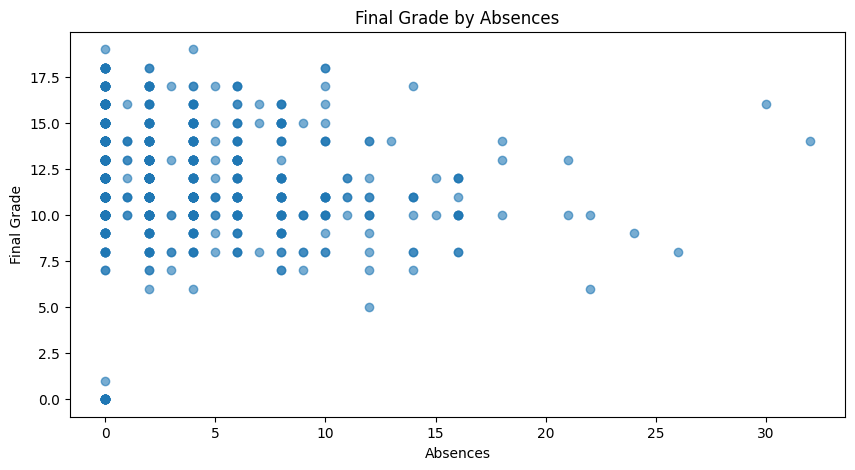

In [20]:
plt.figure(figsize=(10,5))
plt.scatter(df['absences'],df['G3'],alpha=0.6)
plt.xlabel('Absences')
plt.ylabel('Final Grade')
plt.title('Final Grade by Absences')
plt.show()
#

In [21]:
df['absences_group']=pd.cut(df['absences'],bins=[-1,5,10,20, float('inf')],
                            labels=['0-5','6-10','11-20','+21'])
df.groupby('absences_group',observed=True)['G3'].agg(['count','mean','median','min','max']).round(2)


,count,mean,median,min,max
absences_group,,,,,
0-5,478,12.05,12.0,0,19
6-10,122,11.85,11.0,7,18
11-20,41,10.63,11.0,5,17
+21,8,10.75,10.0,6,16


In [22]:
# Does parental education improve student final performanace
df.groupby('Medu')['G3'].agg(['count','mean','median','min','max']).round(2)

,count,mean,median,min,max
Medu,,,,,
0,6,11.67,11.0,10,15
1,143,10.80,11.0,0,18
2,186,11.66,12.0,0,18
3,139,11.92,12.0,0,19
4,175,13.07,13.0,0,19


In [23]:
df.groupby('Fedu')['G3'].agg(['count','mean','median','min','max']).round(2)

,count,mean,median,min,max
Fedu,,,,,
0,7,12.14,11.0,10,18
1,174,10.94,11.0,0,19
2,209,11.78,12.0,0,18
3,131,12.38,12.0,1,18
4,128,12.92,13.0,0,19


<function matplotlib.pyplot.show(close=None, block=None)>

<Figure size 1000x500 with 0 Axes>

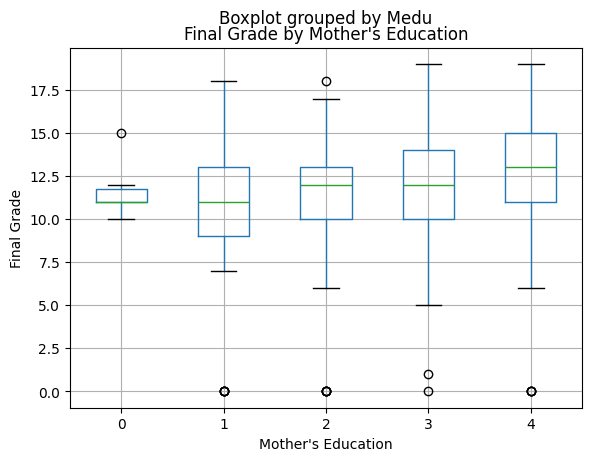

In [24]:
plt.figure(figsize=(10,5))
df.boxplot(column='G3',by='Medu')
plt.xlabel('Mother\'s Education')
plt.ylabel('Final Grade')
plt.title('Final Grade by Mother\'s Education')
plt.show

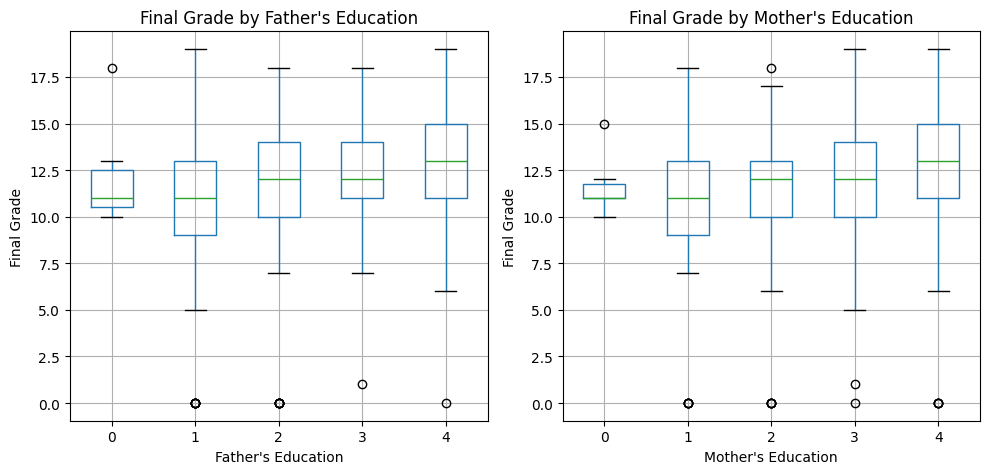

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(10,5))
df.boxplot(column='G3',by='Fedu',ax=axes[0])
axes[0].set_xlabel('Father\'s Education')
axes[0].set_ylabel('Final Grade')
axes[0].set_title('Final Grade by Father\'s Education')
df.boxplot(column='G3',by='Medu',ax=axes[1])
axes[1].set_xlabel('Mother\'s Education')
axes[1].set_ylabel('Final Grade')
axes[1].set_title('Final Grade by Mother\'s Education')
plt.suptitle('')
plt.tight_layout()
plt.show()

In [26]:
#does gender affects students performance
df.groupby('sex')['G3'].agg(['count','mean','median','min','max']).round(2)

,count,mean,median,min,max
sex,,,,,
F,383,12.25,12.0,0,19
M,266,11.41,11.0,0,19


<Figure size 1000x500 with 0 Axes>

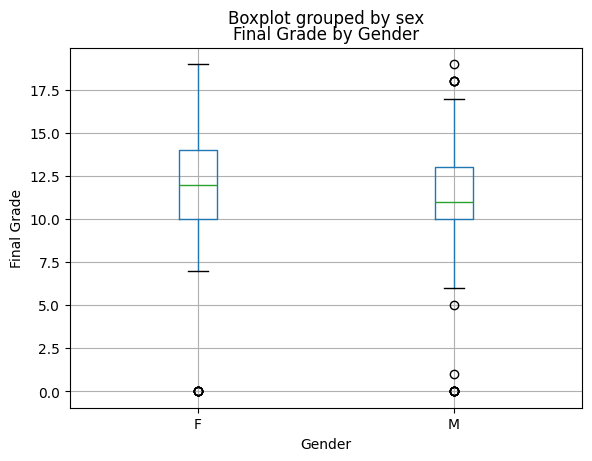

In [27]:
plt.figure(figsize=(10,5))
df.boxplot(column='G3',by='sex')
plt.xlabel('Gender')
plt.ylabel('Final Grade')
plt.title('Final Grade by Gender')
plt.show()

In [28]:
#does previous grades affects final grades
g1_corr=df['G1'].corr(df['G3'])
g2_corr=df['G2'].corr(df['G3'])
print(f'Correlation between G1 and G3:{g1_corr:3f}')
print(f'Correlation between G2 and G3:{g2_corr:3f}')

Correlation between G1 and G3:0.826387
Correlation between G2 and G3:0.918548


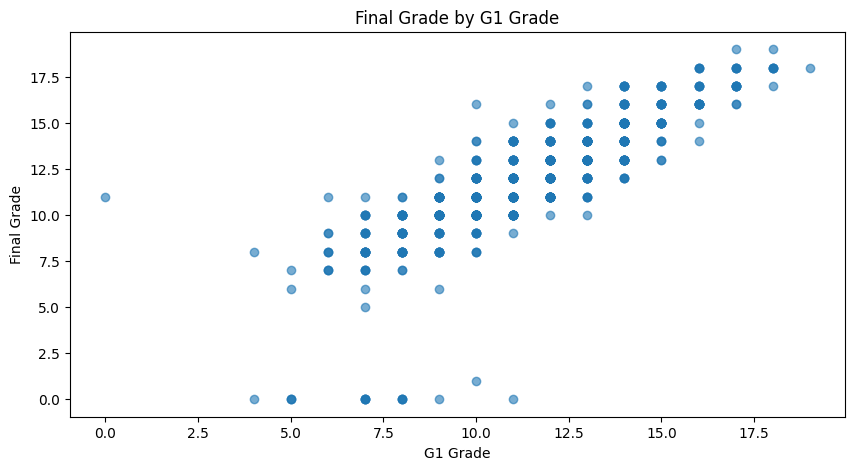

In [29]:
plt.figure(figsize=(10,5))
plt.scatter(df['G1'], df['G3'], alpha=0.6)
plt.xlabel('G1 Grade')
plt.ylabel('Final Grade')
plt.title('Final Grade by G1 Grade')
plt.show()

Text(0.5, 1.0, 'Final Grade by G2 Grade')

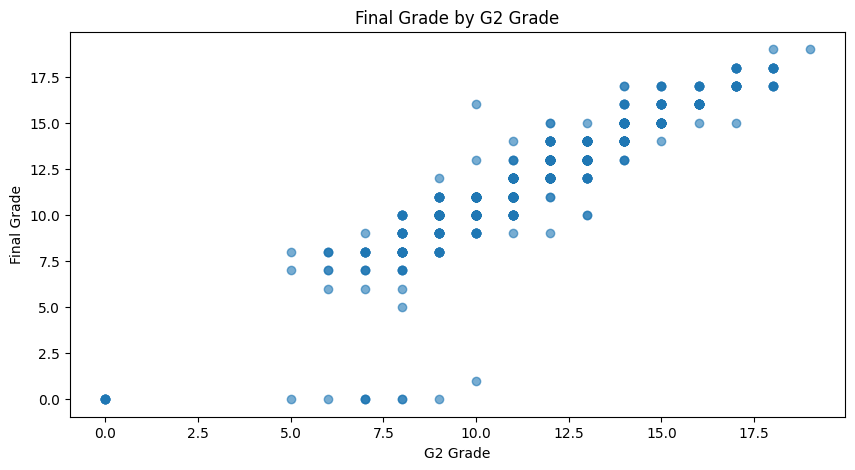

In [30]:
plt.figure(figsize=(10,5))
plt.scatter(df['G2'], df['G3'], alpha=0.6)
plt.xlabel('G2 Grade')
plt.ylabel('Final Grade')
plt.title('Final Grade by G2 Grade')

## Academic Risk Analysis

In [53]:
# academic risk analysis
df['G3'].agg(['count','mean','median','min','max']).round(2)

,G3
count,649.00
mean,11.91
median,12.00
min,0.00
max,19.00


In [52]:
# count student with very low final grades
for threshold in [5,8,10]:
  count= (df['G3']<threshold).sum()
  print(f'Number of students with final grade < {threshold}: {count}')

Number of students with final grade < 5: 16
Number of students with final grade < 8: 30
Number of students with final grade < 10: 100


In [33]:
for threshold in [5,8,10]:
  count= (df['G3']<threshold).sum()
  percentage= (count/len(df))*100
  print(f'Percentage of students with final grade <{threshold}:{count} student {percentage:.1f}%')

Percentage of students with final grade <5:16 student 2.5%
Percentage of students with final grade <8:30 student 4.6%
Percentage of students with final grade <10:100 student 15.4%


In [54]:
from matplotlib.colors import Normalize
# creating risk variable
df['academic_risk']=np.where(df['G3']<10, 'At Risk', 'Not At Risk')
df['academic_risk'].value_counts()
print(df['academic_risk'].value_counts())
risk_summary=(df['academic_risk'].value_counts()/len(df))*100
risk_summary.round(2)

academic_risk
Not At Risk    549
At Risk        100
Name: count, dtype: int64


,count
academic_risk,
Not At Risk,84.59
At Risk,15.41


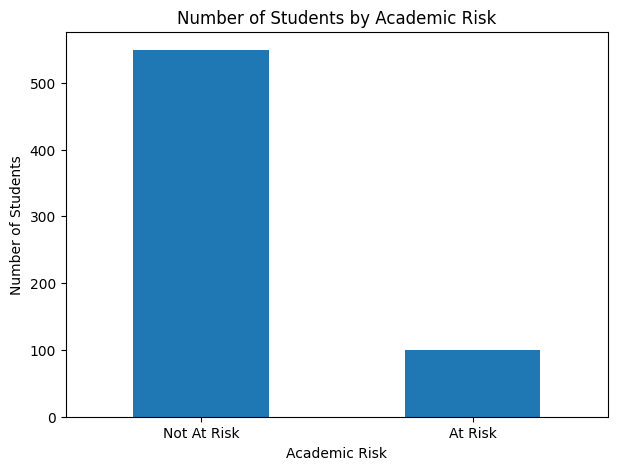

In [35]:
plt.figure(figsize=(7,5))
df['academic_risk'].value_counts().plot(kind='bar')
plt.xlabel('Academic Risk')
plt.ylabel('Number of Students')
plt.title('Number of Students by Academic Risk')
plt.xticks(rotation=0)
plt.show()

In [36]:
#comparing academic risk with other variables
df.groupby('academic_risk')[['G1','G2','G3']].agg(['count','mean','median','min','max']).round(2).T

academic_risk  At Risk  Not At Risk
G1 count        100.00       549.00
   mean           7.78        12.06
   median         8.00        12.00
   min            4.00         0.00
   max           11.00        19.00
G2 count        100.00       549.00
   mean           7.53        12.31
   median         8.00        12.00
   min            0.00         8.00
   max           12.00        19.00
G3 count        100.00       549.00
   mean           6.89        12.82
   median         8.00        13.00
   min            0.00        10.00
   max            9.00        19.00

In [37]:
df.groupby('academic_risk')[['studytime','absences']].agg(['count','mean','median','min','max']).round(2).T


academic_risk     At Risk  Not At Risk
studytime count    100.00       549.00
          mean       1.61         1.99
          median     1.50         2.00
          min        1.00         1.00
          max        4.00         4.00
absences  count    100.00       549.00
          mean       4.61         3.49
          median     2.50         2.00
          min        0.00         0.00
          max       26.00        32.00

In [38]:
pd.crosstab(df['academic_risk'],df['sex'],normalize='index').mul(100).round(1)

sex,F,M
academic_risk,,
At Risk,50.0,50.0
Not At Risk,60.7,39.3


In [39]:
df.groupby('academic_risk')[['Medu','Fedu']].agg(['count','mean','median','min','max']).round(2).T

academic_risk  At Risk  Not At Risk
Medu count      100.00       549.00
     mean         2.13         2.58
     median       2.00         3.00
     min          1.00         0.00
     max          4.00         4.00
Fedu count      100.00       549.00
     mean         1.93         2.38
     median       2.00         2.00
     min          1.00         0.00
     max          4.00         4.00

In [40]:
# Checking the failure variable
failure_risk= pd.crosstab(df['failures'],df['academic_risk'],normalize='index').mul(100).round(1)
failure_risk

academic_risk,At Risk,Not At Risk
failures,,
0,9.3,90.7
1,45.7,54.3
2,50.0,50.0
3,64.3,35.7


In [49]:
failure_counts=df['failures'].value_counts().sort_index()
failure_counts

,count
failures,
0,549
1,70
2,16
3,14


## Machine Learning Models

In [55]:
# feature selection and preparing the dataset for the model
features=['G1','G2','age','studytime','absences','Medu','Fedu','failures']
x= df[features]
y=df['academic_risk']
x.head()

,G1,G2,age,studytime,absences,Medu,Fedu,failures
0,0,11,18,2,4,4,4,0
1,9,11,17,2,2,1,1,0
2,12,13,15,2,6,1,1,0
3,14,14,15,3,0,4,2,0
4,11,13,16,2,0,3,3,0


In [57]:
print(y.value_counts())

academic_risk
Not At Risk    549
At Risk        100
Name: count, dtype: int64


In [60]:
# encoding the target variable
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
y=le.fit_transform(y)
print(y[:10])

[1 1 1 1 1 1 1 1 1 1]


In [62]:
# spliting the data
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
print(x_train.shape)
print(x_test.shape)


(519, 8)
(130, 8)


In [99]:
# building the model
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, classification_report,precision_score,recall_score,f1_score,confusion_matrix)
model=DecisionTreeClassifier(random_state=42)
model.fit(x_train,y_train)
y_pred=model.predict(x_test)

In [100]:
print('Accuracy:',accuracy_score(y_test,y_pred))
print('Precision:',precision_score(y_test,y_pred))
print('Recall:',recall_score(y_test,y_pred))
print('F1 Score:',f1_score(y_test,y_pred))
print('\n',classification_report(y_test,y_pred))

Accuracy: 0.9
Precision: 0.9636363636363636
Recall: 0.9217391304347826
F1 Score: 0.9422222222222222

               precision    recall  f1-score   support

           0       0.55      0.73      0.63        15
           1       0.96      0.92      0.94       115

    accuracy                           0.90       130
   macro avg       0.76      0.83      0.79       130
weighted avg       0.92      0.90      0.91       130



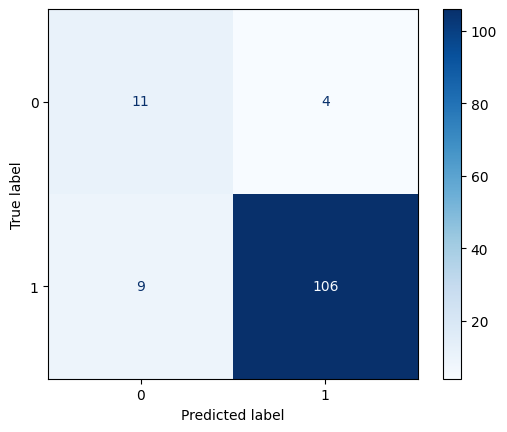

In [101]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
cm=confusion_matrix(y_test,y_pred)
disp=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=le.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.show()

In [102]:
from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier(class_weight='balanced')
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
print('Accuracy:',accuracy_score(y_test,y_pred))
print('Precision:',precision_score(y_test,y_pred))
print('Recall:',recall_score(y_test,y_pred))
print('F1 Score:',f1_score(y_test,y_pred))
print('\n',classification_report(y_test,y_pred))

Accuracy: 0.9076923076923077
Precision: 0.9557522123893806
Recall: 0.9391304347826087
F1 Score: 0.9473684210526315

               precision    recall  f1-score   support

           0       0.59      0.67      0.62        15
           1       0.96      0.94      0.95       115

    accuracy                           0.91       130
   macro avg       0.77      0.80      0.79       130
weighted avg       0.91      0.91      0.91       130



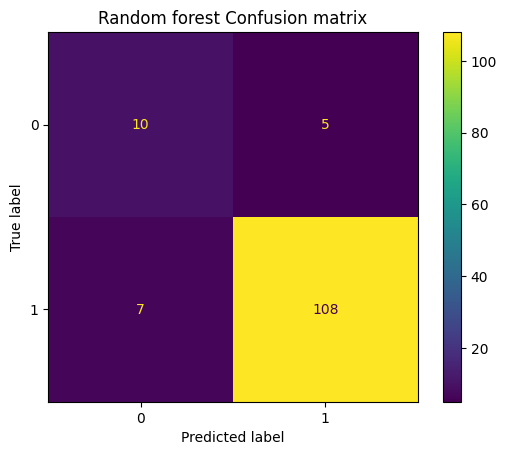

In [103]:
ConfusionMatrixDisplay.from_predictions(y_test,y_pred)
plt.title('Random forest Confusion matrix')
plt.show()

## Feature Importance

In [108]:
importance= pd.DataFrame({'feature':features,'importance':model.feature_importances_})
importance.sort_values(by='importance',ascending=False,inplace=True)
print(importance)

     feature  importance
0         G1    0.378391
1         G2    0.330505
7   failures    0.071809
4   absences    0.054909
2        age    0.051383
5       Medu    0.040829
6       Fedu    0.039531
3  studytime    0.032643


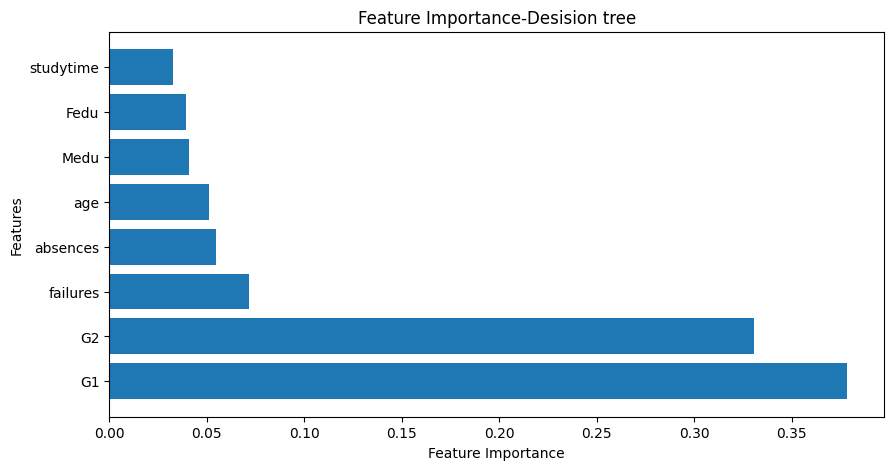

In [109]:
plt.figure(figsize=(10,5))
plt.barh(importance['feature'],importance['importance'])
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Feature Importance-Desision tree')
plt.show()

In [106]:
relevance= pd.DataFrame({'feature':features,'importance':model.feature_importances_})
relevance.sort_values(by='importance',ascending=False,inplace=True)
print(relevance)

     feature  importance
0         G1    0.378391
1         G2    0.330505
7   failures    0.071809
4   absences    0.054909
2        age    0.051383
5       Medu    0.040829
6       Fedu    0.039531
3  studytime    0.032643


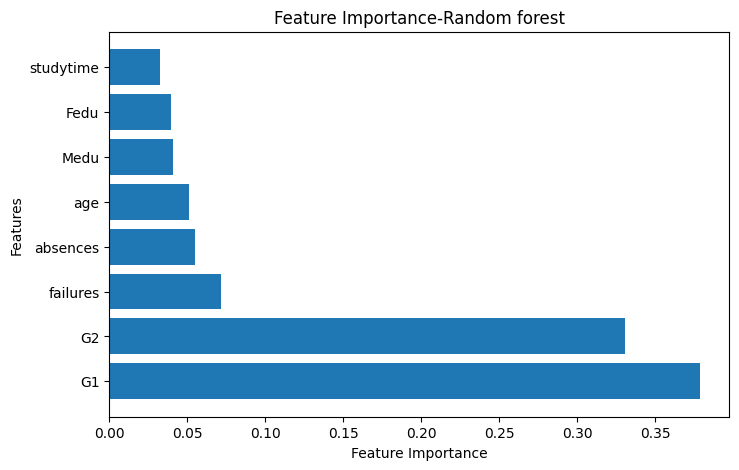

In [107]:
plt.figure(figsize=(8,5))
plt.barh(relevance['feature'],relevance['importance'])
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Feature Importance-Random forest')
plt.show()

## Conclusion
The project explored factors associated with student academic performance and academic risk
### key findings


*   Most students scored between 10 and 15

*   Female students slightly out performed male students

*   Previous grades (G1 and G2) were the stongest predictors of final performance
*   Increased absences were associated with lower academic perfromance.


*   Study time alone was not a strong predictor of academic risk.


*   A random forest classifier achieved approximately 91% accuraccy in identifying students at risk.

These findings suggest that early academic performance and attendance records can be used to identify students who may benefit from additional academic support.



#